# Leak Checks

This notebook is the central place for HFE system leak analysis. It runs the system $N_2$ pressure-decay test, the main-loop vacuum rate-of-rise test, and the reservoir O-ring leak comparisons through `orca.leaks`.


## Notebook roadmap

1. Locate the repository root and raw data directory.
2. Run the system-pressure leak analysis through `orca.leaks`.
3. Run the main-loop vacuum rate-of-rise analysis with the physically correct fixed-volume model.
4. Display the updated pressure-decay and rate-of-rise figures inline.
5. Run the reservoir O-ring comparison from raw pressure logs.


In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import orca
import orca.leaks as leak_tools

importlib.reload(leak_tools)
importlib.reload(orca)


<module 'orca' from '/home/aamy/Documents/hfe-system/analysis/src/orca/__init__.py'>

In [2]:
NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

RAW_DIR = REPO_ROOT / 'data' / 'raw'

print(f'ORCA: {orca.ORCA_MEANING}')
print(f'Repo root: {REPO_ROOT}')


ORCA: Operational Recirculation and Cryogenic Analysis
Repo root: /home/aamy/Documents/hfe-system


## 1. System pressure leak checks

Only include true tank / 1 atm $N_2$ gas-trap runs here. The 2026-03-13 log is excluded because the pressure sensor after the pump was connected to the reservoir for the EDPM O-ring test.


In [3]:
SYSTEM_PRESSURE_LOGS = [
    RAW_DIR / 'log_20260311_114721.csv',
    RAW_DIR / 'log_20260312_172440.csv',
]

system_results = [leak_tools.analyze_system_pressure_log(path) for path in SYSTEM_PRESSURE_LOGS]
system_summary = leak_tools.system_pressure_summary_table(system_results)
display(
    system_summary.round(
        {
            'elapsed_h': 3,
            'fit_asymptote_bar_abs': 4,
            'fit_k_per_h': 5,
            'mean_pressure_bar_abs': 3,
            'leak_mbar_l_s': 4,
            'hfe_loss_l_year': 2,
            'rmse_mbar': 1,
        }
    )
)


,log_file,elapsed_h,fit_asymptote_bar_abs,fit_k_per_h,mean_pressure_bar_abs,top_gas_total_pressure_bar_abs,hfe_vapor_partial_pressure_bar_abs,n2_partial_pressure_bar_abs,top_gas_hfe_mole_fraction,leak_mbar_l_s,hfe_loss_l_year,rmse_mbar
0,log_20260311_114721.csv,2.915,1.0117,-0.47035,1.154,1.150758,0.137508,1.01325,0.119494,0.1258,29.90,8.5
1,log_20260312_172440.csv,17.119,1.0327,-0.47983,1.154,1.146849,0.133599,1.01325,0.116492,0.1246,29.67,10.0


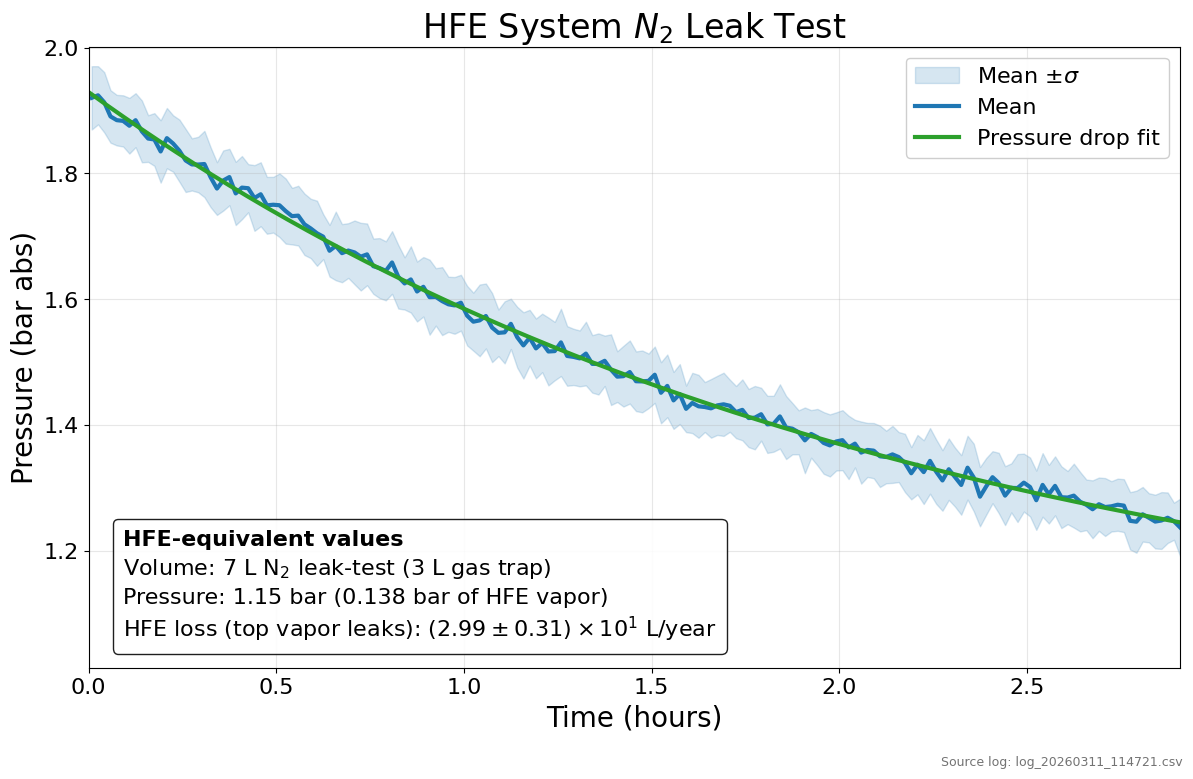

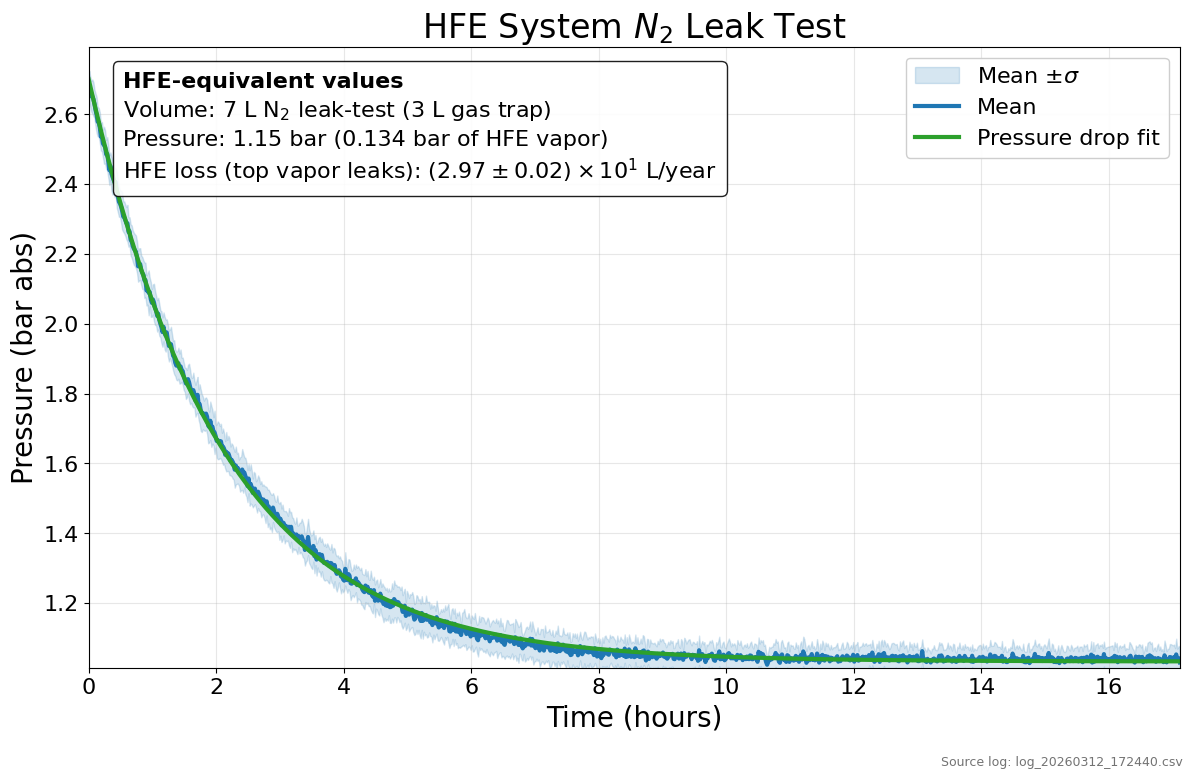

In [4]:
for result in system_results:
    fig, _ = leak_tools.plot_system_pressure_result(result)
    display(fig)
    plt.close(fig)


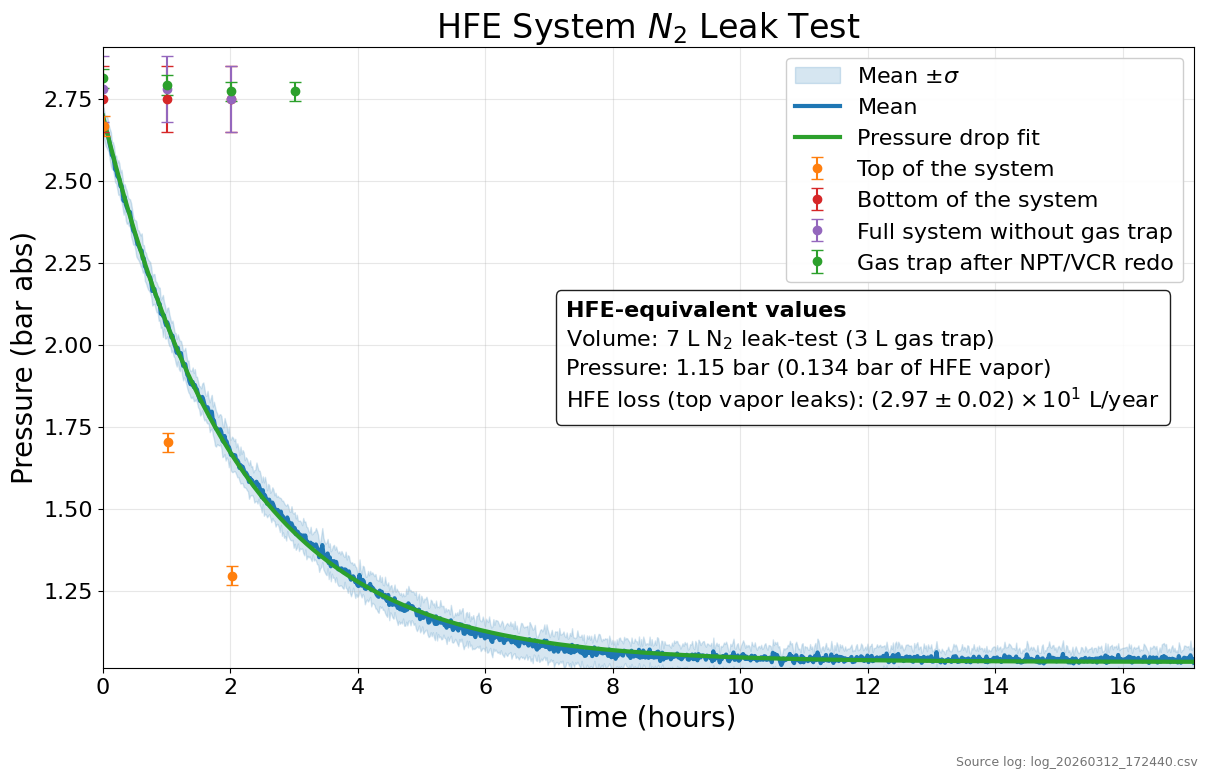

In [5]:
top_system_result = leak_tools.analyze_system_pressure_log(RAW_DIR / 'log_20260312_172440.csv')
fig, axis = leak_tools.plot_system_pressure_result(top_system_result)

tank_gauge_psi = (top_system_result.averaged.pressure_abs_bar - leak_tools.P_ATM_BAR) * 14.5037738
alignment_order = np.argsort(tank_gauge_psi)
top_system_start_time_h = np.interp(
    24.0,
    tank_gauge_psi[alignment_order],
    top_system_result.averaged.time_h[alignment_order],
)
top_system_time_h = top_system_start_time_h + np.array([0.0, 1.0, 2.0], dtype=float)
top_system_gauge_psi = np.array([24.0, 10.0, 4.1], dtype=float)
top_system_pressure_bar_abs = leak_tools.P_ATM_BAR + top_system_gauge_psi / 14.5037738

top_gauge_min_psi = -30.0 * 0.491154
top_gauge_max_psi = 60.0
top_gauge_span_psi = top_gauge_max_psi - top_gauge_min_psi
top_gauge_quarter_psi = 0.25 * top_gauge_span_psi

def top_gauge_sigma_psi(reading_psig: float) -> float:
    in_end_quarter = (
        reading_psig <= top_gauge_min_psi + top_gauge_quarter_psi
        or reading_psig >= top_gauge_max_psi - top_gauge_quarter_psi
    )
    accuracy_fraction = 0.02 if in_end_quarter else 0.01
    return accuracy_fraction * top_gauge_span_psi / np.sqrt(3.0)

top_system_sigma_bar = np.array(
    [top_gauge_sigma_psi(reading) / 14.5037738 for reading in top_system_gauge_psi],
    dtype=float,
)
bottom_system_start_time_h = top_system_result.averaged.time_h[0]
bottom_system_time_h = bottom_system_start_time_h + np.array([0.0, 1.0, 2.0], dtype=float)
bottom_system_pressure_bar_abs = np.array([2.75, 2.75, 2.75], dtype=float)
bottom_system_sigma_bar = np.full(3, 0.1, dtype=float)
full_system_no_gas_trap_time_h = bottom_system_start_time_h + np.array([0.0, 1.0, 2.0], dtype=float)
full_system_no_gas_trap_pressure_bar_abs = np.array([2.78, 2.78, 2.75], dtype=float)
full_system_no_gas_trap_sigma_bar = np.full(3, 0.1, dtype=float)
gas_trap_gauge_bar = np.array([1.8, 1.78, 1.76, 1.76], dtype=float)
gas_trap_gauge_psi = gas_trap_gauge_bar * 14.5037738
gas_trap_start_time_h = np.interp(
    gas_trap_gauge_psi[0],
    tank_gauge_psi[alignment_order],
    top_system_result.averaged.time_h[alignment_order],
)
gas_trap_time_h = gas_trap_start_time_h + np.array([0.0, 1.0, 2.0, 3.0], dtype=float)
gas_trap_pressure_bar_abs = leak_tools.P_ATM_BAR + gas_trap_gauge_bar
gas_trap_sigma_bar = np.array(
    [top_gauge_sigma_psi(reading) / 14.5037738 for reading in gas_trap_gauge_psi],
    dtype=float,
)

axis.errorbar(
    top_system_time_h,
    top_system_pressure_bar_abs,
    yerr=top_system_sigma_bar,
    fmt='o',
    capsize=4,
    color='tab:orange',
    label='Top of the system',
)
axis.errorbar(
    bottom_system_time_h,
    bottom_system_pressure_bar_abs,
    yerr=bottom_system_sigma_bar,
    fmt='o',
    capsize=4,
    color='tab:red',
    label='Bottom of the system',
)
axis.errorbar(
    full_system_no_gas_trap_time_h,
    full_system_no_gas_trap_pressure_bar_abs,
    yerr=full_system_no_gas_trap_sigma_bar,
    fmt='o',
    capsize=4,
    color='tab:purple',
    label='Full system without gas trap',
)
axis.errorbar(
    gas_trap_time_h,
    gas_trap_pressure_bar_abs,
    yerr=gas_trap_sigma_bar,
    fmt='o',
    capsize=4,
    color='tab:green',
    label='Gas trap after NPT/VCR redo',
)
current_ymin, current_ymax = axis.get_ylim()
axis.set_ylim(
    current_ymin,
    max(
        current_ymax,
        float(np.max(bottom_system_pressure_bar_abs + bottom_system_sigma_bar)),
        float(np.max(gas_trap_pressure_bar_abs + gas_trap_sigma_bar)),
        float(
            np.max(
                full_system_no_gas_trap_pressure_bar_abs
                + full_system_no_gas_trap_sigma_bar
            )
        ),
    )
    + 0.03,
)
legend = axis.legend(loc='best', fontsize=16, framealpha=0.95)
for artist in list(axis.artists):
    if isinstance(artist, leak_tools.AnchoredOffsetbox):
        artist.remove()
legend_fontsize = float(legend.get_texts()[0].get_fontsize()) if legend.get_texts() else 16.0
value_box_lines = [
    f"Volume: {leak_tools.NITROGEN_LEAK_TEST_VOLUME_L:.0f} L N$_2$ leak-test ({top_system_result.top_gas_trap.gas_trap_volume_l:.0f} L gas trap)",
    f"Pressure: {top_system_result.top_gas_trap.total_pressure_abs_bar:.2f} bar ({top_system_result.top_gas_trap.hfe_vapor_pressure_abs_bar:.3f} bar of HFE vapor)",
    "HFE loss (top vapor leaks): "
    + leak_tools.format_leak_annotation_line(top_system_result.leak, unit='L/year', use_hfe_loss=True),
]
point_clouds = [
    leak_tools.annotation_sample_cloud(
        axis,
        top_system_result.averaged.time_h,
        top_system_result.averaged.pressure_abs_bar - top_system_result.averaged.pressure_sigma_bar,
    ),
    leak_tools.annotation_sample_cloud(
        axis,
        top_system_result.averaged.time_h,
        top_system_result.averaged.pressure_abs_bar,
    ),
    leak_tools.annotation_sample_cloud(
        axis,
        top_system_result.averaged.time_h,
        top_system_result.averaged.pressure_abs_bar + top_system_result.averaged.pressure_sigma_bar,
    ),
    leak_tools.annotation_sample_cloud(axis, top_system_time_h, top_system_pressure_bar_abs),
    leak_tools.annotation_sample_cloud(axis, bottom_system_time_h, bottom_system_pressure_bar_abs),
    leak_tools.annotation_sample_cloud(
        axis,
        full_system_no_gas_trap_time_h,
        full_system_no_gas_trap_pressure_bar_abs,
    ),
    leak_tools.annotation_sample_cloud(axis, gas_trap_time_h, gas_trap_pressure_bar_abs),
]
if top_system_result.fit_curve_time_h is not None and top_system_result.fit_curve_pressure_bar is not None:
    point_clouds.append(
        leak_tools.annotation_sample_cloud(
            axis,
            top_system_result.fit_curve_time_h,
            top_system_result.fit_curve_pressure_bar,
        )
    )
leak_tools.add_best_value_box(
    axis,
    'HFE-equivalent values',
    value_box_lines,
    legend_fontsize,
    point_clouds,
    legend,
)
display(fig)
plt.close(fig)


## 2. Vacuum pressure-rise checks

This is the previous main-loop-only isolated vacuum test. For a fixed isolated volume, the physically correct packaged model is a weighted linear fit in absolute pressure versus time. The water-vapor line is shown as a comparison, not as the primary fit model.


In [6]:
VACUUM_RATE_OF_RISE_CASES = [
    leak_tools.build_vacuum_rate_of_rise_case(
        label='Main Loop Vacuum Test',
        data_inhg=[
            ('2025-10-30 17:30', -28.0),
            ('2025-10-31 17:30', -26.0),
            ('2025-11-03 09:45', -22.0),
            ('2025-11-04 16:30', -20.0),
            ('2025-11-06 11:00', -17.0),
        ],
        volume_l=4.0,
        system_temp_c=21.0,
        source_note='Main-loop vacuum test: 2025-10-30 to 2025-11-06',
    ),
]

vacuum_results = [
    leak_tools.analyze_vacuum_rate_of_rise_case(case)
    for case in VACUUM_RATE_OF_RISE_CASES
]
vacuum_summary = leak_tools.vacuum_rate_of_rise_summary_table(vacuum_results)
display(
    vacuum_summary.round(
        {
            'elapsed_h': 3,
            'start_pressure_bar_abs': 4,
            'end_pressure_bar_abs': 4,
            'rise_rate_mbar_h': 2,
            'gas_load_mbar_l_s': 4,
            'hfe_loss_l_year': 3,
            'water_saturation_bar_abs': 4,
            'start_over_water_sat': 2,
            'end_over_water_sat': 2,
            'rmse_mbar': 1,
        }
    )
)
        


,case,elapsed_h,start_pressure_bar_abs,end_pressure_bar_abs,rise_rate_mbar_h,gas_load_mbar_l_s,hfe_loss_l_year,water_saturation_bar_abs,start_over_water_sat,end_over_water_sat,rmse_mbar
0,Main Loop Vacuum Test,161.5,0.0651,0.4376,2.26,0.0025,0.597,0.0248,2.63,17.66,4.8


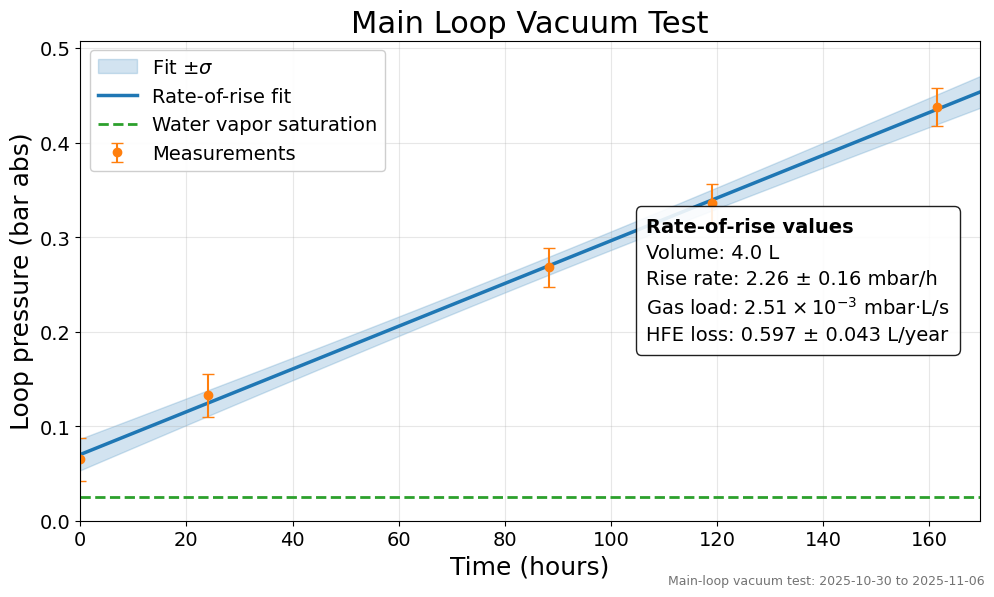

In [7]:
for result in vacuum_results:
    fig, _ = leak_tools.plot_vacuum_rate_of_rise_result(result)
    display(fig)
    plt.close(fig)
        


## 3. Reservoir O-ring leak checks

This section keeps both the old sparse reservoir checks and the newer raw logged reservoir runs.

- The legacy sparse-point Viton and FEP results are kept below for reference.
- The raw logged runs use the same averaging and exponential-fit path as the system pressure-drop section.
- If a raw trace does not show a clear pressure drop, the notebook prints a warning and shows only the measured pressure without a fit.


In [8]:
LEGACY_RESERVOIR_VOLUME_L = 11.0
LEGACY_RESERVOIR_OPERATING_GAUGE_BAR = leak_tools.HFE_VAPOR_GAUGE_BAR
PSI_TO_BAR = 0.0689476

legacy_reservoir_cases = [
    leak_tools.ReservoirLeakCase(
        label='FEP O-ring',
        slug='fep_legacy',
        time_h=np.array([0.0, 19.0 + 2.0 / 60.0], dtype=float),
        pressure_abs_bar=np.array(
            [
                23.0 * PSI_TO_BAR + leak_tools.P_ATM_BAR,
                10.0 * PSI_TO_BAR + leak_tools.P_ATM_BAR,
            ],
            dtype=float,
        ),
        volume_l=LEGACY_RESERVOIR_VOLUME_L,
        operating_gauge_bar=LEGACY_RESERVOIR_OPERATING_GAUGE_BAR,
        x_max_h=leak_tools.DEFAULT_RESERVOIR_XMAX_H,
        y_max_bar=leak_tools.DEFAULT_RESERVOIR_YMAX_BAR,
        source_note='Legacy reservoir test data: FEP O-ring (2 spot measurements)',
    ),
    leak_tools.ReservoirLeakCase(
        label='Viton O-ring',
        slug='viton_legacy',
        time_h=np.array([0.0, 4.0 + 47.0 / 60.0], dtype=float),
        pressure_abs_bar=np.array([1.65, 1.35], dtype=float),
        volume_l=LEGACY_RESERVOIR_VOLUME_L,
        operating_gauge_bar=LEGACY_RESERVOIR_OPERATING_GAUGE_BAR,
        x_max_h=leak_tools.DEFAULT_RESERVOIR_XMAX_H,
        y_max_bar=leak_tools.DEFAULT_RESERVOIR_YMAX_BAR,
        source_note='Legacy reservoir test data: Viton O-ring (2 spot measurements)',
    ),
]

legacy_reservoir_results = [
    leak_tools.analyze_reservoir_case(case)
    for case in legacy_reservoir_cases
]
legacy_reservoir_summary = leak_tools.reservoir_summary_table(legacy_reservoir_results)
legacy_reservoir_summary.insert(1, 'data_source', 'legacy sparse points')
display(
    legacy_reservoir_summary.round(
        {
            'elapsed_h': 3,
            'fit_k_per_h': 5,
            'start_pressure_bar_abs': 3,
            'end_pressure_bar_abs': 3,
            'volume_l': 1,
            'operating_pressure_bar_abs': 3,
            'start_decay_mbar_h': 1,
            'leak_mbar_l_s': 4,
            'hfe_loss_l_year': 2,
        }
    )
)


,case,data_source,elapsed_h,fit_k_per_h,start_pressure_bar_abs,end_pressure_bar_abs,volume_l,operating_pressure_bar_abs,start_decay_mbar_h,leak_mbar_l_s,hfe_loss_l_year
0,FEP O-ring,legacy sparse points,19.033,-0.04376,2.599,1.703,11.0,1.176,69.4,0.0218,5.14
1,Viton O-ring,legacy sparse points,4.783,-0.13318,1.650,1.350,11.0,1.176,84.8,0.0663,15.65


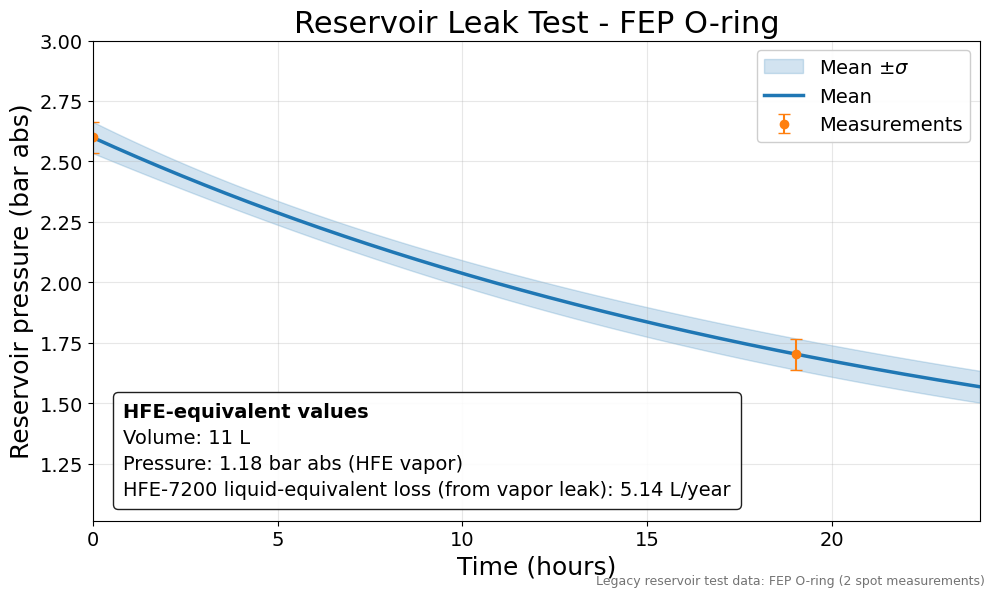

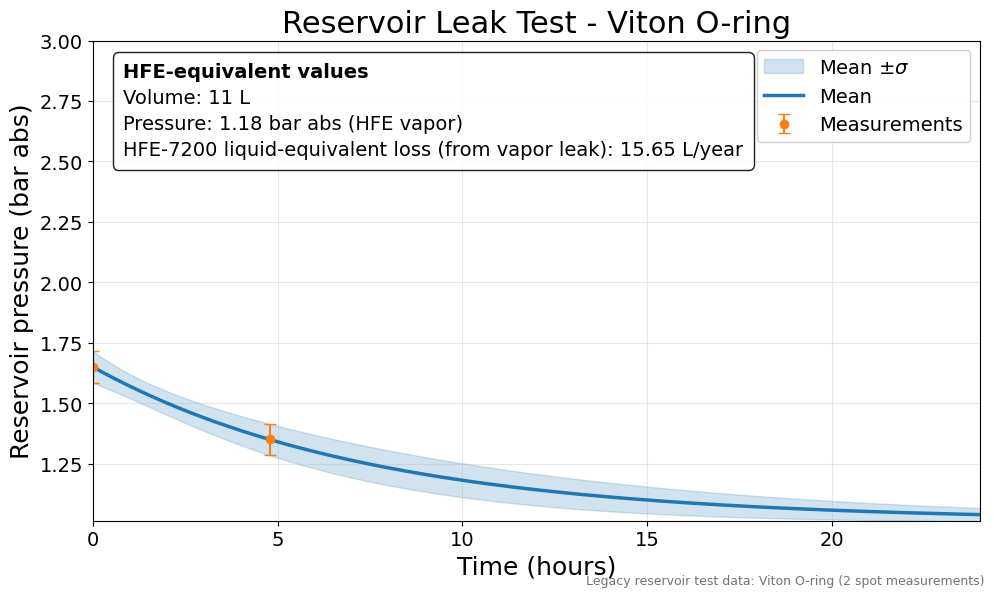

In [9]:
for result in legacy_reservoir_results:
    fig, _ = leak_tools.plot_reservoir_leak_result(result)
    display(fig)
    plt.close(fig)


### 3.2 Raw logged reservoir runs

These are the runs to use for the planned Viton vs FEP vs EDPM comparison.

The precise reservoir measurements below use `pump_pressure_after_bar_abs`, because that sensor was connected to the reservoir during the long EDPM hold in `tc_log_20260316_142912.csv`. If a raw trace does not support a proper pressure-drop fit, the notebook prints a warning and leaves the plot as measurements only.


In [10]:
RESERVOIR_VOLUME_L = 11.0
RESERVOIR_OPERATING_GAUGE_BAR = leak_tools.HFE_VAPOR_GAUGE_BAR
RESERVOIR_PRESSURE_COLUMN = 'pump_pressure_after_bar_abs'
RESERVOIR_PRESSURE_GAUGE_COLUMN = 'pump_pressure_after_bar'
RESERVOIR_BIN_WIDTH_MIN = 1.0

reservoir_log_configs = [
    {
        'label': 'Viton O-ring',
        'slug': 'viton',
        'log_path': RAW_DIR / 'tc_log_20260318_110914.csv',
        'pressure_abs_column': RESERVOIR_PRESSURE_COLUMN,
        'pressure_gauge_column': RESERVOIR_PRESSURE_GAUGE_COLUMN,
    },
    {
        'label': 'FEP O-ring',
        'slug': 'fep',
        'log_path': None,
        'pressure_abs_column': RESERVOIR_PRESSURE_COLUMN,
        'pressure_gauge_column': RESERVOIR_PRESSURE_GAUGE_COLUMN,
    },
    {
        'label': 'EDPM O-ring',
        'slug': 'edpm',
        'log_path': RAW_DIR / 'tc_log_20260316_142912.csv',
        'pressure_abs_column': RESERVOIR_PRESSURE_COLUMN,
        'pressure_gauge_column': RESERVOIR_PRESSURE_GAUGE_COLUMN,
    },
]

pending_reservoir_logs = [
    config['label']
    for config in reservoir_log_configs
    if config['log_path'] is None
]
if pending_reservoir_logs:
    print('Pending reservoir raw logs:', ', '.join(pending_reservoir_logs))

reservoir_results = [
    leak_tools.analyze_reservoir_pressure_log(
        csv_path=config['log_path'],
        label=config['label'],
        slug=config['slug'],
        volume_l=RESERVOIR_VOLUME_L,
        operating_gauge_bar=RESERVOIR_OPERATING_GAUGE_BAR,
        pressure_abs_column=config['pressure_abs_column'],
        pressure_gauge_column=config['pressure_gauge_column'],
        bin_width_min=RESERVOIR_BIN_WIDTH_MIN,
    )
    for config in reservoir_log_configs
    if config['log_path'] is not None
]

reservoir_result_by_label = {result.label: result for result in reservoir_results}

if not reservoir_results:
    raise ValueError('Add at least one reservoir raw log path in reservoir_log_configs.')


Pending reservoir raw logs: FEP O-ring


/home/aamy/Documents/hfe-system/analysis/src/orca/leaks.py:1334: UserWarning: Viton O-ring: pressure-drop fit not constrained; fit skipped.
  ) = analyze_pressure_drop_log(
/home/aamy/Documents/hfe-system/analysis/src/orca/leaks.py:1334: UserWarning: EDPM O-ring: no clear pressure drop; fit skipped.
  ) = analyze_pressure_drop_log(


/home/aamy/Documents/hfe-system/analysis/src/orca/leaks.py:1334: UserWarning: EDPM O-ring: no clear pressure drop; fit skipped.
  ) = analyze_pressure_drop_log(


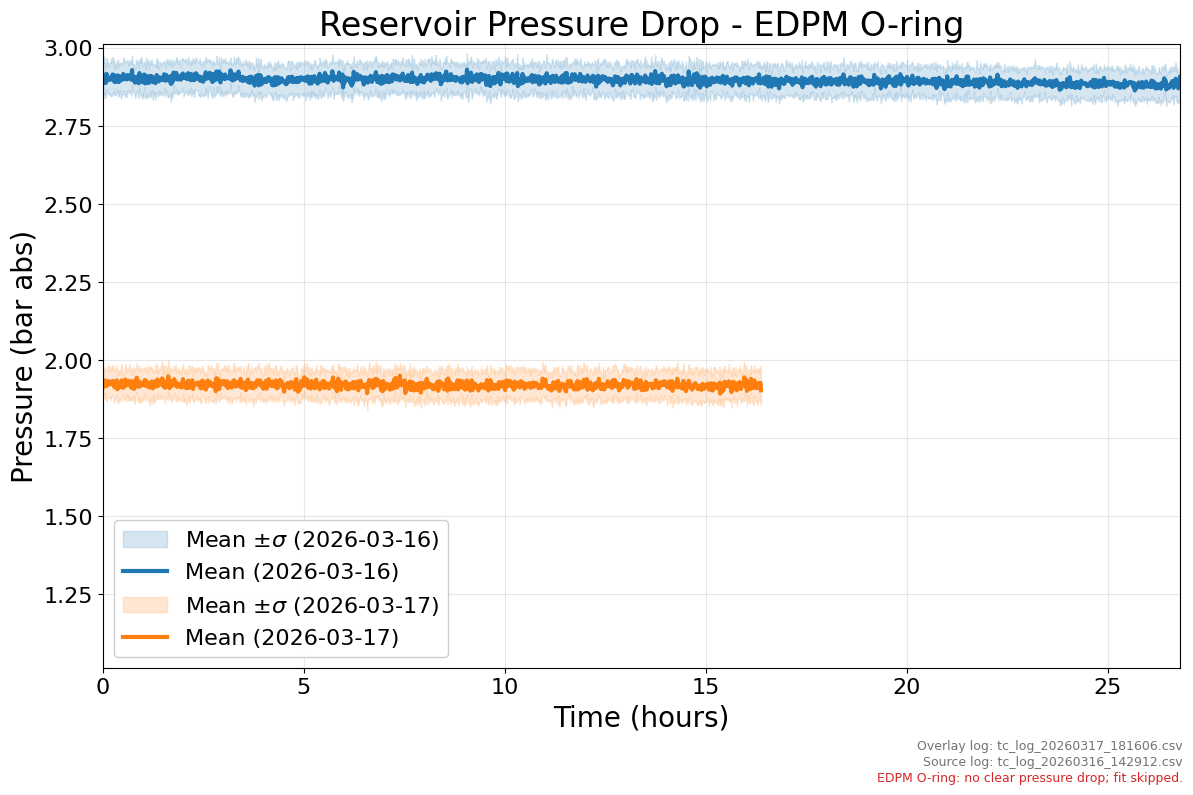

In [11]:
edpm_primary_result = reservoir_result_by_label['EDPM O-ring']
edpm_overlay_log = RAW_DIR / 'tc_log_20260317_181606.csv'

fig, axis = leak_tools.plot_reservoir_pressure_log_result(edpm_primary_result)
axis.collections[0].set_label(r"Mean $\pm\sigma$ (2026-03-16)")
axis.lines[0].set_label('Mean (2026-03-16)')

edpm_overlay_result = leak_tools.analyze_reservoir_pressure_log(
    csv_path=edpm_overlay_log,
    label=edpm_primary_result.label,
    slug='edpm_20260317_181606',
    volume_l=RESERVOIR_VOLUME_L,
    operating_gauge_bar=RESERVOIR_OPERATING_GAUGE_BAR,
    pressure_abs_column=RESERVOIR_PRESSURE_COLUMN,
    pressure_gauge_column=RESERVOIR_PRESSURE_GAUGE_COLUMN,
    bin_width_min=RESERVOIR_BIN_WIDTH_MIN,
)

axis.fill_between(
    edpm_overlay_result.averaged.time_h,
    edpm_overlay_result.averaged.pressure_abs_bar
    - edpm_overlay_result.averaged.pressure_sigma_bar,
    edpm_overlay_result.averaged.pressure_abs_bar
    + edpm_overlay_result.averaged.pressure_sigma_bar,
    color='tab:orange',
    alpha=0.18,
    label=r"Mean $\pm\sigma$ (2026-03-17)",
)
axis.plot(
    edpm_overlay_result.averaged.time_h,
    edpm_overlay_result.averaged.pressure_abs_bar,
    color='tab:orange',
    linewidth=3.0,
    label='Mean (2026-03-17)',
)
axis.legend(loc='best', fontsize=16, framealpha=0.95)
fig.text(
    0.99,
    0.052,
    f'Overlay log: {edpm_overlay_log.name}',
    ha='right',
    va='bottom',
    fontsize=9,
    color='0.45',
)
display(fig)
plt.close(fig)


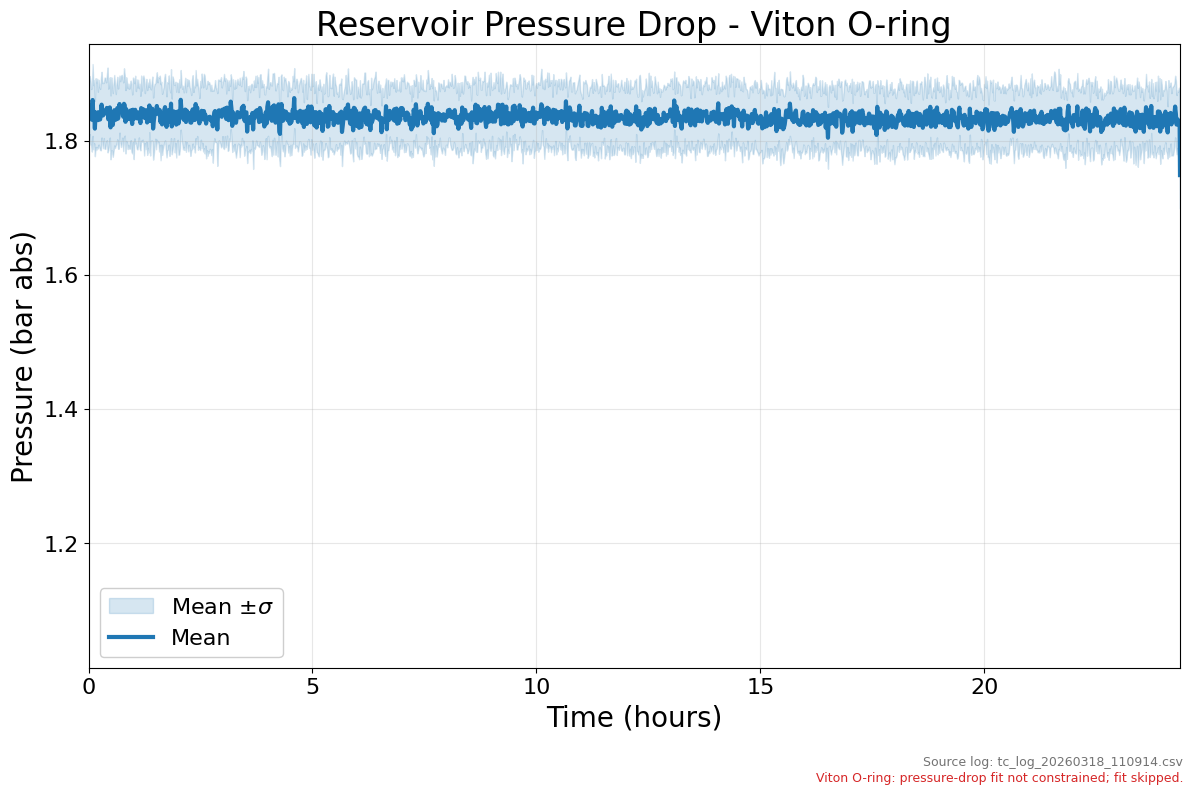

In [12]:
viton_result = reservoir_result_by_label['Viton O-ring']

fig, _ = leak_tools.plot_reservoir_pressure_log_result(viton_result)
display(fig)
plt.close(fig)


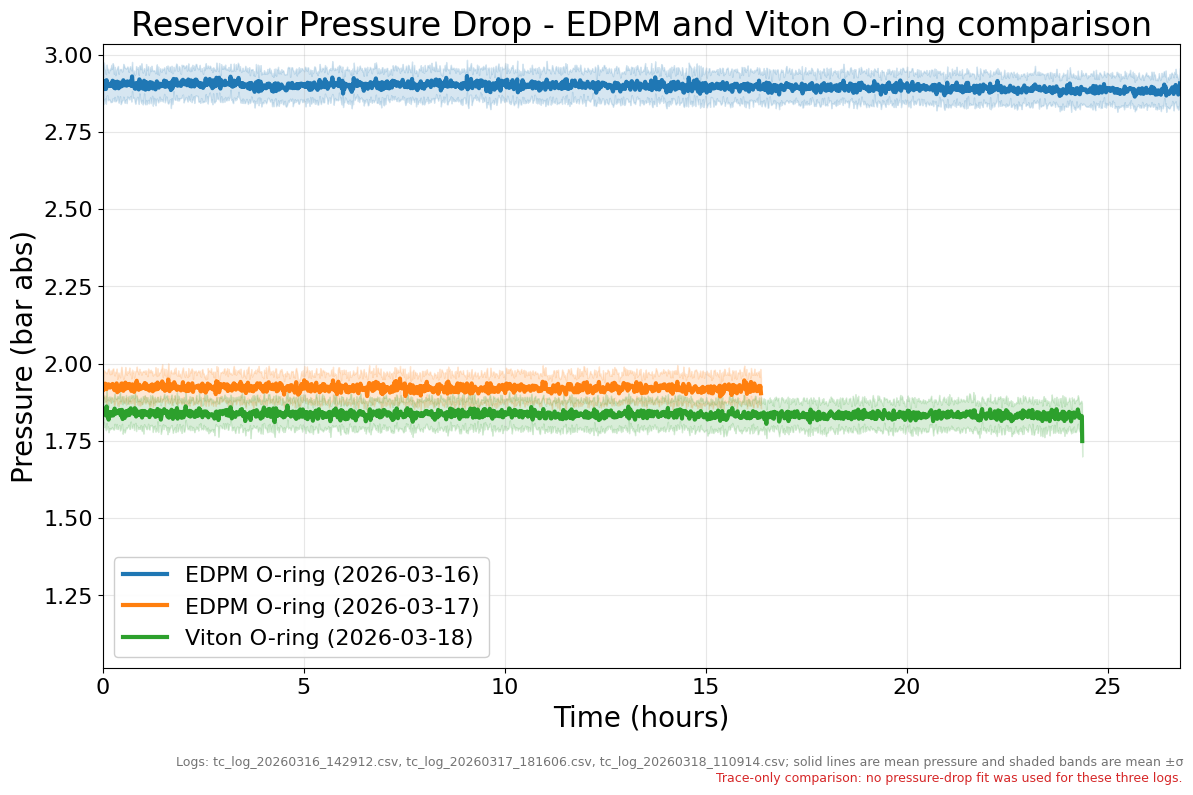

In [13]:
def plot_reservoir_pressure_log_overlay(traces, *, title, source_note, warning=None):
    fig, axis = plt.subplots(figsize=(12, 8))
    y_samples = []
    x_max_h = 0.0

    for trace in traces:
        result = trace['result']
        axis.fill_between(
            result.averaged.time_h,
            result.averaged.pressure_abs_bar - result.averaged.pressure_sigma_bar,
            result.averaged.pressure_abs_bar + result.averaged.pressure_sigma_bar,
            color=trace['color'],
            alpha=trace.get('alpha', 0.18),
            label=trace.get('band_label', '_nolegend_'),
        )
        axis.plot(
            result.averaged.time_h,
            result.averaged.pressure_abs_bar,
            color=trace['color'],
            linewidth=3.0,
            label=trace['line_label'],
        )
        y_samples.extend(
            [
                result.averaged.pressure_abs_bar - result.averaged.pressure_sigma_bar,
                result.averaged.pressure_abs_bar + result.averaged.pressure_sigma_bar,
            ]
        )
        x_max_h = max(x_max_h, float(result.averaged.time_h[-1]))

    y_all = np.concatenate(y_samples)
    y_min = float(np.min(y_all))
    y_max = float(np.max(y_all))
    y_pad = max(0.04 * (y_max - y_min), 0.03)

    axis.set_xlim(0.0, x_max_h)
    axis.set_ylim(leak_tools.P_ATM_BAR, y_max + y_pad)
    axis.set_xlabel('Time (hours)', fontsize=20)
    axis.set_ylabel('Pressure (bar abs)', fontsize=20)
    axis.set_title(title, fontsize=24)
    axis.tick_params(axis='both', labelsize=16)
    axis.grid(True, alpha=0.3)
    axis.legend(loc='best', fontsize=16, framealpha=0.95)

    fig.tight_layout(rect=(0.0, 0.06, 1.0, 1.0))
    fig.text(
        0.99,
        0.032,
        source_note,
        ha='right',
        va='bottom',
        fontsize=9,
        color='0.45',
    )
    if warning is not None:
        fig.text(
            0.99,
            0.012,
            warning,
            ha='right',
            va='bottom',
            fontsize=9,
            color='tab:red',
        )
    return fig, axis


comparison_traces = [
    {
        'result': edpm_primary_result,
        'color': 'tab:blue',
        'line_label': 'EDPM O-ring (2026-03-16)',
    },
    {
        'result': edpm_overlay_result,
        'color': 'tab:orange',
        'line_label': 'EDPM O-ring (2026-03-17)',
    },
    {
        'result': viton_result,
        'color': 'tab:green',
        'line_label': 'Viton O-ring (2026-03-18)',
    },
]

fig, _ = plot_reservoir_pressure_log_overlay(
    comparison_traces,
    title='Reservoir Pressure Drop - EDPM and Viton O-ring comparison',
    source_note=(
        'Logs: tc_log_20260316_142912.csv, '
        'tc_log_20260317_181606.csv, '
        'tc_log_20260318_110914.csv; '
        'solid lines are mean pressure and shaded bands are mean ±σ'
    ),
    warning='Trace-only comparison: no pressure-drop fit was used for these three logs.',
)
display(fig)
plt.close(fig)
